In [73]:
#directorio raiz donde esta el framework
%cd D:\tesis\scrpt pyton\interfaz_correccion\interfaz_correccion\efficient-kan\src\efficient_kan

D:\tesis\scrpt pyton\interfaz_correccion\interfaz_correccion\efficient-kan\src\efficient_kan


C:\Users\ferro\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [74]:
import pandas as pd
import numpy as np
import os
import joblib
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc, ConfusionMatrixDisplay
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import OneCycleLR
from entmax import sparsemax, entmax15
from lion_pytorch import Lion
from kan import KANLinear, KAN
import shap
import lime
import lime.lime_tabular
# Configuración para usar la GPU si está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from sklearn.preprocessing import LabelEncoder

In [3]:
# Establecer semillas para reproducibilidad
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [12]:
# Cargar el dataset desde un archivo Excel
daf = pd.read_excel('D:\\tesis\\Modelo_extraccion_no\\dataset_extraccion_up_low_bimax.xlsx')
daf.columns

Index(['Paciente', 'Edad', 'Genero', 'Etnia', 'Apiñamiento sup',
       'Apiñamiento inf', 'Overbite', 'Overjet', 'SNA', 'SNB', 'ANB',
       'A-Macna', 'Pg-Macna', 'IMPA', 'SN-MP', 'SN-GoGn', 'Fh-Npog',
       'Ngo-GoMe', 'NS-SGn', 'U1-Sn', 'U1-PP', 'U1-NA(mm)', 'U1-Na(°)',
       'L1-NB(mm)', 'L1-NB(°)', 'U1-L1', 'L1-Apog', 'U1-Apog', 'Sts-Sti',
       'UL-E-Line', 'LL-E-Line', 'UlSn-SnPmn', 'LLB'-B'Pog'',
       'discrepancia total inferior', 'discrepancia total superior',
       'Clasificación  esqueletica', 'Relación molar', 'Relación premolar',
       'Relacion canina', 'Clase real', 'Extraccion / no extraccion inf',
       'Extraccion / no extraccion sup', 'Extraccion tejidos blandos',
       'Extraccion / no extraccion', 'Tipo de extraccióin global'],
      dtype='object')

In [13]:
daf.drop(columns=["Extraccion / no extraccion inf","Extraccion / no extraccion sup", "Extraccion / no extraccion","Paciente","Extraccion tejidos blandos",'discrepancia total inferior', 'discrepancia total superior',"Clase real"],inplace=True)
daf

,Edad,Genero,Etnia,Apiñamiento sup,Apiñamiento inf,Overbite,Overjet,SNA,SNB,ANB,...,Sts-Sti,UL-E-Line,LL-E-Line,UlSn-SnPmn,LLB'-B'Pog',Clasificación esqueletica,Relación molar,Relación premolar,Relacion canina,Tipo de extraccióin global
0,39,F,afrocolombiana,-4.00,-16.0,5.945810,2.202145,84.573158,82.968865,-1.604293,...,0.220212,-4.876738,0.516159,88.976967,153.536996,Clase 3,clase 1,clase 1,clase 2,Extracción bima
1,29,F,meztizo,-2.50,-5.5,2.797421,1.165594,81.689042,76.753278,4.935764,...,0.233121,-4.594830,-1.478628,76.829501,150.843664,Clase 2,clase 1,clase 1,clase 1,Extracción bima
2,27,F,meztizo,-0.70,-0.4,-1.864948,0.233121,88.991416,88.257801,0.733615,...,0.233121,-3.142670,-2.029610,75.193551,132.754262,Clase 3,clase 3,clase 3,clase 3,No extracción
3,42,F,meztizo,4.69,-2.5,3.729886,2.098068,81.962304,77.149397,4.812907,...,0.000000,-4.233241,-2.474814,58.780804,136.972533,Clase 2,clase 2,clase 2,clase 2,No extracción
4,33,F,meztizo,7.17,-3.8,3.263663,1.165594,85.601294,80.637686,4.963608,...,0.233121,-1.258132,2.175378,75.805316,158.163527,Clase 2,clase 3,clase 3,clase 1,Extracción inf.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,40,M,meztizo,0.00,-1.0,-0.308762,-4.322586,85.785459,86.081896,0.296437,...,0.000000,-6.782278,-4.331714,64.730585,168.402454,Clase 3,clase 3,clase 3,clase 3,Extracción bima
496,23,M,meztizo,3.00,-2.0,2.778801,4.013824,81.468412,78.959218,2.509194,...,0.308762,-1.294142,-1.249473,86.513197,141.985936,Clase 2,clase 1,clase 1,clase 1,No extracción
497,19,M,meztizo,-6.00,-5.0,5.633917,3.442950,85.643270,80.706450,4.936821,...,0.938992,-3.556261,-0.994024,30.703272,138.691411,Clase 2,clase 2,clase 2,clase 2,No extracción
498,34,M,afrocolombiana,6.00,1.0,0.599442,-3.296960,85.662749,87.259750,7.077501,...,0.899167,1.513549,5.711739,95.258436,154.902959,Clase 2,clase 2,clase 2,clase 2,Extracción bima


In [14]:
daf["Tipo de extraccióin global"].value_counts()

Tipo de extraccióin global
No extracción      274
Extracción bima    196
Extracción inf.     17
Extracción sup.     13
Name: count, dtype: int64

In [15]:
LabelEncoder_1=LabelEncoder()
daf["Genero"]=LabelEncoder_1.fit_transform(daf["Genero"])
daf["Etnia"]=LabelEncoder_1.fit_transform(daf["Etnia"])
daf["Clasificación  esqueletica"]=LabelEncoder_1.fit_transform(daf["Clasificación  esqueletica"])
daf["Relación molar"]=LabelEncoder_1.fit_transform(daf["Relación molar"])
daf["Relacion canina"]=LabelEncoder_1.fit_transform(daf["Relacion canina"])
daf["Relación premolar"]=LabelEncoder_1.fit_transform(daf["Relación premolar"])

In [16]:
df = daf[daf['Tipo de extraccióin global'] != 'Extracción inf.']

In [17]:
df["Tipo de extraccióin global"].value_counts()

Tipo de extraccióin global
No extracción      274
Extracción bima    196
Extracción sup.     13
Name: count, dtype: int64

In [18]:
df['Tipo de extraccióin global'] = df['Tipo de extraccióin global'].map({'Extracción bima': 1, 'No extracción': 0,"Extracción sup.":1})
Labels = df['Tipo de extraccióin global']
Features = df.drop(['Tipo de extraccióin global'],axis=1)
X_train, X_test, y_train, y_test = train_test_split(Features, Labels, test_size=0.2, stratify=Labels, random_state=42)

C:\Users\ferro\AppData\Local\Temp\ipykernel_28264\3576407119.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Tipo de extraccióin global'] = df['Tipo de extraccióin global'].map({'Extracción bima': 1, 'No extracción': 0,"Extracción sup.":1})


In [19]:
# Guardar los conjuntos de datos de la extracción superior
joblib.dump((X_train, y_train), 'D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Train_superior.pkl')
joblib.dump((X_test, y_test), 'D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Test_superior.pkl')

['D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Test_superior.pkl']

# BALANCED ANY

In [75]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Train_superior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Test_superior.pkl')

In [76]:
smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

In [77]:
X_train_unbalance= torch.tensor(X_train_resampled_s.values, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test.values, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

In [78]:
# Verificar el balance de las clases
unique_classes, class_counts = torch.unique(Y_train_unbalance, return_counts=True)
for cls, count in zip(unique_classes, class_counts):
    print(f'Clase {cls.item()}: {count.item()} muestras')

Clase 0.0: 219 muestras
Clase 1.0: 219 muestras


## KAN

In [79]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [80]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac sup\\any_bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")


Fold 1


100%|██████████| 11/11 [00:00<00:00, 47.05it/s, accuracy=0.467, loss=0.703, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac sup\any_bal\best_model.pth con val_loss: 0.6834688385327657
Epoch 1, Train Loss: 0.7115657329559326, Val Loss: 0.6834688385327657, Val Accuracy: 0.5


100%|██████████| 11/11 [00:00<00:00, 45.60it/s, accuracy=0.633, loss=0.702, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac sup\any_bal\best_model.pth con val_loss: 0.6712023814519247
Epoch 2, Train Loss: 0.6917356848716736, Val Loss: 0.6712023814519247, Val Accuracy: 0.5


...

Epoch 8, Train Loss: 0.6457043615254489, Val Loss: 0.6481116612752279, Val Accuracy: 0.46603261431058246


100%|██████████| 11/11 [00:00<00:00, 46.85it/s, accuracy=0.548, loss=0.628, lr=0.0001]


Epoch 9, Train Loss: 0.6341099630702626, Val Loss: 0.6299751996994019, Val Accuracy: 0.5117753644784292


100%|██████████| 11/11 [00:00<00:00, 45.86it/s, accuracy=0.484, loss=0.624, lr=0.0001]


Epoch 10, Train Loss: 0.6250334598801353, Val Loss: 0.6273702581723531, Val Accuracy: 0.5013586978117625
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 75.25773195876289%, F1-score: 75.17691009016129%, Precision: 75.16096943389402%, Recall: 75.25773195876289%


In [81]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 76.00 ± 4.96%
F1-score: 75.67 ± 6.57%
Precisión (Precision): 76.38 ± 6.51%
Recall: 76.00 ± 4.96%

Métricas del Conjunto de Prueba:
Precisión: 78.56 ± 4.49%
F1-score: 78.55 ± 4.50%
Precisión (Precision): 78.74 ± 4.60%
Recall: 78.56 ± 4.49%


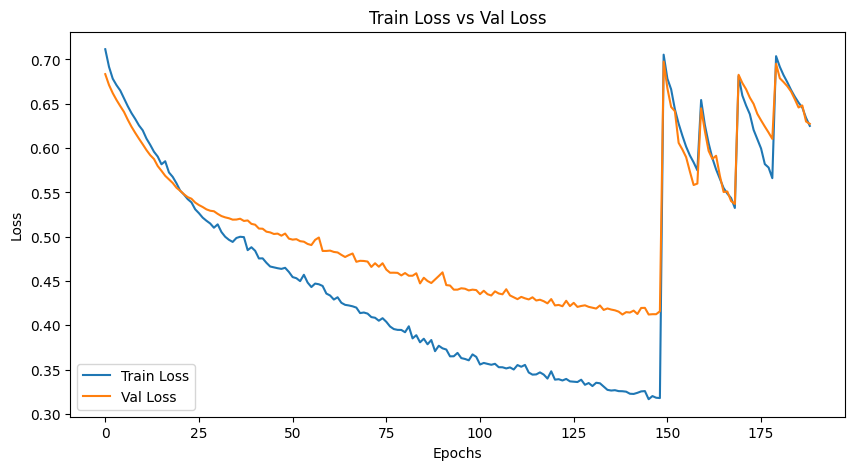

In [82]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['accuracy', 'f1', 'recall', 'roc_auc']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_anybal_{scoring}.pkl"
    joblib.dump(best_model, model_path)

WARNING! The apex is not installed so fp16 is not available.
Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\qhoptim\pyt\qhadam.py:133: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha) (Trig

Steps	Train Err	Val Metric (error_rate)
100	0.6055	0.197
200	0.4215	0.1667
300	0.3092	0.1212
400	0.2095	0.0909
500	0.2511	0.0758
600	0.0757	0.0455
700	0.0576	0.0455
800	0.121	0.0606
900	0.0482	0.0606
1000	0.0262	0.0455
1100	0.0255	0.0455
1200	0.1209	0.0606
1300	0.0737	0.0606
1400	0.0287	0.0606
1500	0.0063	0.0455
1600	0.0083	0.0455
1700	0.029	0.0303
1800	0.0776	0.0455
1900	0.0597	0.0455
2000	0.0109	0.0455
2100	0.0239	0.0606
2200	0.0485	0.0303
2300	0.0497	0.0303
2400	0.1502	0.0303
2500	0.029	0.0303
BREAK. There is no improvment for 500 steps
Total training time: 61.8 seconds
Best step:  1700
Best Val Metric:  0.030303030303030304
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for accuracy: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation accuracy: 0.9109979101358412
Fitting 5 folds for each of 10 candidates, t

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6221	0.1212
200	0.3658	0.1212
300	0.1518	0.0909
400	0.1335	0.0455
500	0.3239	0.0455
600	0.158	0.0303
700	0.1143	0.0455
800	0.1237	0.0758
900	0.0504	0.0606
1000	0.0725	0.0606
1100	0.0747	0.0455
1200	0.0208	0.0606
1300	0.0414	0.0303
1400	0.0689	0.0303
1500	0.0494	0.0303
1600	0.0525	0.0303
1700	0.0436	0.0303
1800	0.0465	0.0303
1900	0.0137	0.0303
2000	0.0947	0.0455
2100	0.015	0.0455
2200	0.1301	0.0455
2300	0.0308	0.0455
2400	0.0367	0.0455
2500	0.0221	0.0455
BREAK. There is no improvment for 500 steps
Total training time: 42.6 seconds
Best step:  600
Best Val Metric:  0.030303030303030304
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation f1: 0.9045397657118697
Fitting 5 folds for each of 10 candidates, totalling 50

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6169	0.1515
200	0.4627	0.1061
300	0.3483	0.0909
400	0.3509	0.0606
500	0.1329	0.0758
600	0.1981	0.0303
700	0.0865	0.0606
800	0.0242	0.0455
900	0.1319	0.0606
1000	0.082	0.0606
1100	0.0513	0.0455
1200	0.1238	0.0152
1300	0.0204	0.0152
1400	0.029	0.0303
1500	0.0281	0.0152
1600	0.0423	0.0303
1700	0.0352	0.0303
1800	0.0212	0.0455
1900	0.0413	0.0152
2000	0.0627	0.0455
2100	0.0498	0.0303
2200	0.0519	0.0455
2300	0.0559	0.0455
2400	0.0036	0.0455
2500	0.0138	0.0455
BREAK. There is no improvment for 500 steps
Total training time: 43.8 seconds
Best step:  1200
Best Val Metric:  0.015151515151515152
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for recall: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation recall: 0.908925745884139
Fitting 5 folds for each of 10 candidates, tota

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Entrenando con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.6204	0.4091
200	0.7761	0.4394
300	0.7236	0.3939
400	0.5682	0.2727
500	0.4615	0.2576
600	0.6205	0.1667
700	0.5661	0.1364
800	0.5235	0.1364
900	0.3873	0.1212
1000	0.3855	0.1212
1100	0.2904	0.1364
1200	0.3017	0.1364
1300	0.2901	0.1061
1400	0.275	0.1061
1500	0.3357	0.0909
1600	0.2608	0.0758
1700	0.2778	0.0606
1800	0.4008	0.0606
1900	0.4576	0.0606
2000	0.3267	0.0758
2100	0.3658	0.0455
2200	0.3665	0.0455
2300	0.3715	0.0455
2400	0.1888	0.0455
2500	0.3307	0.0455
2600	0.2683	0.0455
BREAK. There is no improvment for 500 steps
Total training time: 42.8 seconds
Best step:  2100
Best Val Metric:  0.045454545454545456
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for roc_auc: {'output_dropout': 0.3, 'num_tr

In [83]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\superior\\bal\\anybal")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 200,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.4,
    'early_stopping_steps': 500,
    'depth': 4
}

# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")



Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (535) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5457	0.1321
200	0.5456	0.1321
300	0.0855	0.1321
400	0.0707	0.0755
500	0.1024	0.0755
600	0.2289	0.0943
700	0.1124	0.0566
800	0.0012	0.0755
900	0.1746	0.0943
1000	0.2184	0.1132
1100	0.004	0.0755
1200	0.0077	0.0755
1300	0.1358	0.0755
1400	0.0674	0.0943
1500	0.0337	0.0755
1600	0.0133	0.0755
1700	0.0066	0.0566
1800	0.0087	0.0755
1900	0.1103	0.0755
2000	0.0857	0.0755
2100	0.0165	0.0755
2200	0.0018	0.0755
2300	0.0043	0.0755
2400	0.0043	0.0755
2500	0.0089	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 69.4 seconds
Best step:  700
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 92.04545454545455%, F1-score: 92.04237258286075%, Test accuracy: 86.5979381443299%, Test F1-score: 86.61529645434264%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.00

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5464	0.1887
200	0.4473	0.1509
300	0.5069	0.0943
400	0.4897	0.0566
500	0.1178	0.0377
600	0.0641	0.0566
700	0.2132	0.0755
800	0.0489	0.0755
900	0.0607	0.0566
1000	0.0271	0.0566
1100	0.0158	0.0566
1200	0.0578	0.0566
1300	0.0016	0.0755
1400	0.0094	0.0377
1500	0.0083	0.0377
1600	0.0477	0.0377
1700	0.0103	0.0377
1800	0.0025	0.0377
1900	0.0673	0.0755
2000	0.0077	0.0566
2100	0.4357	0.0566
2200	0.173	0.0377
2300	0.1446	0.0377
2400	0.0033	0.0377
2500	0.0047	0.0377
BREAK. There is no improvment for 500 steps
Total training time: 71.6 seconds
Best step:  500
Best Val Metric:  0.03773584905660377
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 89.77272727272727%, F1-score: 89.65611852935797%, Test accuracy: 84.5360824742268%, Test F1-score: 84.58591785136433%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.00

...

Steps	Train Err	Val Metric (error_rate)
100	0.6241	0.1321
200	0.4025	0.1321
300	0.0985	0.1321
400	0.31	0.1132
500	0.0615	0.1509
600	0.0904	0.1321
700	0.075	0.1321
800	0.0111	0.1132
900	0.0898	0.1132
1000	0.0753	0.1132
1100	0.0665	0.1132
1200	0.0694	0.1132
1300	0.0185	0.1132
1400	0.0459	0.0943
1500	0.0052	0.1132
1600	0.033	0.1321
1700	0.0048	0.0943
1800	0.0162	0.0943
1900	0.0315	0.0943
2000	0.0063	0.0943
2100	0.0032	0.1132
2200	0.0913	0.0943
2300	0.0128	0.0943
2400	0.0244	0.1132
2500	0.0008	0.1132
BREAK. There is no improvment for 500 steps
Total training time: 67.9 seconds
Best step:  1400
Best Val Metric:  0.09433962264150944
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 88.50574712643679%, F1-score: 88.46294937637565%, Test accuracy: 89.69072164948454%, Test F1-score: 89.61385422318683%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.4594	0.2075
200	0.2854	0.1698
300	0.1382	0.1698
400	0.1447	0.1509
500	0.0046	0.1321
600	0.0547	0.1509
700	0.0535	0.1321
800	0.0436	0.1321
900	0.0552	0.1321
1000	0.0282	0.1321
1100	0.0024	0.1509
1200	0.0297	0.1321
1300	0.0184	0.1321
1400	0.0592	0.1321
1500	0.0021	0.1321
1600	0.0171	0.1321
1700	0.0218	0.1132
1800	0.0143	0.1132
1900	0.0196	0.1132
2000	0.0115	0.1132
2100	0.0194	0.0943
2200	0.0411	0.0943
2300	0.0162	0.1132
2400	0.1584	0.1132
2500	0.0001	0.1132
2600	0.0025	0.1132
BREAK. There is no improvment for 500 steps
Total training time: 68.6 seconds
Best step:  2100
Best Val Metric:  0.09433962264150944
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 89.65517241379311%, F1-score: 89.60586567566212%, Test accuracy: 86.5979381443299%, Test F1-score: 86.57757247994485%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5958	0.1515
200	0.3542	0.1667
300	0.4723	0.1212
400	0.1805	0.0909
500	0.1026	0.0909
600	0.1005	0.0909
700	0.0847	0.0455
800	0.1148	0.0758
900	0.1219	0.0758
1000	0.0749	0.0758
1100	0.0676	0.0909
1200	0.0849	0.0455
1300	0.072	0.0455
1400	0.0342	0.0606
1500	0.0716	0.0606
1600	0.0131	0.0152
1700	0.0439	0.0303
1800	0.0654	0.0152
1900	0.0319	0.0303
2000	0.0512	0.0455
2100	0.0295	0.0455
2200	0.0225	0.0606
2300	0.0104	0.0455
2400	0.0268	0.0455
2500	0.0071	0.0455
BREAK. There is no improvment for 500 steps
Total training time: 67.4 seconds
Best step:  1600
Best Val Metric:  0.015151515151515152
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\superior\bal\anybal\best_model_fold_1.pth


In [84]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 89.95 ± 1.15%
F1-score: 89.93 ± 1.17%
Precisión (Precision): 90.65 ± 1.18%
Recall: 89.95 ± 1.15%

Métricas del Conjunto de Prueba:
Precisión: 87.84 ± 2.56%
F1-score: 87.82 ± 2.53%
Precisión (Precision): 87.93 ± 2.52%
Recall: 87.84 ± 2.56%


# Balanced PCA

In [85]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Train_superior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Test_superior.pkl')

In [86]:
smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

In [87]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_resampled_s)
X_train_pca= pca.transform(X_train_resampled_s)
X_test_pca=pca.transform(X_test)

In [88]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)


## KAN

In [89]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [90]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac sup\\pca_bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")


Fold 1


 45%|████▌     | 5/11 [00:00<00:00, 46.73it/s, accuracy=0.625, loss=0.684, lr=0.0001]

100%|██████████| 11/11 [00:00<00:00, 40.64it/s, accuracy=0.367, loss=0.696, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac sup\pca_bal\best_model.pth con val_loss: 0.6979373097419739
Epoch 1, Train Loss: 0.6979475834152915, Val Loss: 0.6979373097419739, Val Accuracy: 0.5


100%|██████████| 11/11 [00:00<00:00, 52.59it/s, accuracy=0.5, loss=0.688, lr=0.0001] 


...

Epoch 8, Train Loss: 0.6553393656557257, Val Loss: 0.6758614381154379, Val Accuracy: 0.45561594764391583


100%|██████████| 11/11 [00:00<00:00, 46.08it/s, accuracy=0.516, loss=0.654, lr=0.0001]


Epoch 9, Train Loss: 0.6472126082940535, Val Loss: 0.6731754541397095, Val Accuracy: 0.45561594764391583


100%|██████████| 11/11 [00:00<00:00, 46.39it/s, accuracy=0.484, loss=0.651, lr=0.0001]


Epoch 10, Train Loss: 0.637435875155709, Val Loss: 0.6709432403246561, Val Accuracy: 0.45561594764391583
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 77.31958762886599%, F1-score: 77.37330953586049%, Precision: 77.49288253081289%, Recall: 77.31958762886599%


In [91]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 67.79 ± 6.83%
F1-score: 67.13 ± 7.70%
Precisión (Precision): 68.92 ± 6.92%
Recall: 67.79 ± 6.83%

Métricas del Conjunto de Prueba:
Precisión: 74.23 ± 1.73%
F1-score: 74.24 ± 1.77%
Precisión (Precision): 74.51 ± 1.82%
Recall: 74.23 ± 1.73%


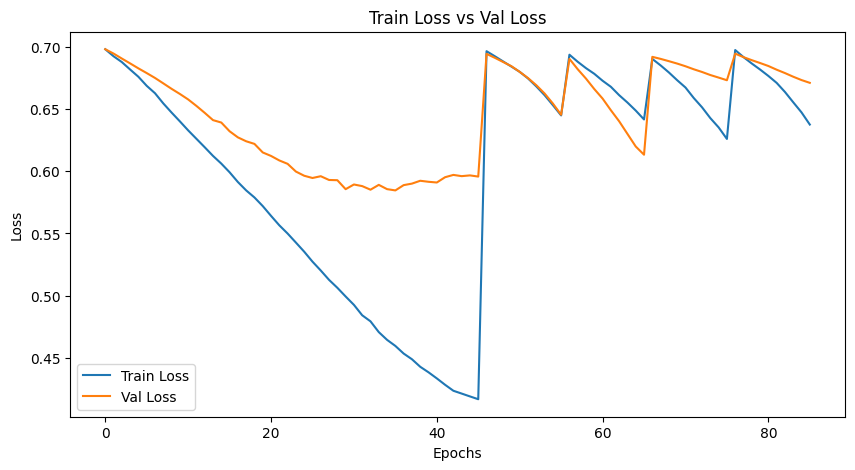

In [92]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [46]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['accuracy', 'f1', 'recall', 'roc_auc']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_pcabal_{scoring}.pkl"
    joblib.dump(best_model, model_path)

Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6366	0.3788
200	0.6587	0.3182
300	0.6697	0.2424
400	0.4948	0.1818
500	0.4487	0.1667
600	0.5041	0.1515
700	0.479	0.0909
800	0.4617	0.0909
900	0.3254	0.1061
1000	0.2682	0.1212
1100	0.3843	0.1212
1200	0.5129	0.1364
1300	0.4505	0.1364
1400	0.6309	0.1515
1500	0.3145	0.1515
1600	0.2838	0.1515
1700	0.3648	0.1515
1800	0.3157	0.1515
1900	0.2906	0.1364
2000	0.3313	0.1364
2100	0.2705	0.1515
2200	0.3346	0.1515
2300	0.2524	0.1061
2400	0.2709	0.1212
2500	0.4007	0.1212
BREAK. There is no improvment for 500 steps
Total training time: 64.3 seconds
Best step:  700
Best Val Metric:  0.09090909090909091
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for accuracy: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation accuracy: 0.8492685475444096
Fitting 5 folds for each of 10 candidates,

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7247	0.2273
200	0.4829	0.1212
300	0.3877	0.1364
400	0.475	0.1515
500	0.2033	0.1818
600	0.2748	0.1515
700	0.1484	0.1667
800	0.1349	0.1667
900	0.2986	0.1364
1000	0.1923	0.1364
1100	0.4275	0.1364
1200	0.2744	0.1212
1300	0.3357	0.1212
1400	0.2191	0.1212
1500	0.1743	0.0909
1600	0.2387	0.0909
1700	0.3884	0.0909
1800	0.255	0.1212
1900	0.2165	0.1061
2000	0.2349	0.1061
2100	0.1592	0.1061
2200	0.1567	0.1061
2300	0.2375	0.0909
2400	0.1395	0.1061
2500	0.1536	0.1061
BREAK. There is no improvment for 500 steps
Total training time: 62.6 seconds
Best step:  1500
Best Val Metric:  0.09090909090909091
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation f1: 0.8347178785646638
Fitting 5 folds for each of 10 candidates, totalling 50

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5609	0.3485
200	0.5944	0.1818
300	0.4215	0.1212
400	0.351	0.1364
500	0.2404	0.1364
600	0.3142	0.1667
700	0.4301	0.1667
800	0.3408	0.1818
900	0.3107	0.1667
1000	0.3414	0.1515
1100	0.2137	0.1515
1200	0.2803	0.1515
1300	0.2649	0.1515
1400	0.3156	0.1364
1500	0.3462	0.1515
1600	0.3909	0.1515
1700	0.1757	0.1515
1800	0.1844	0.1667
1900	0.3412	0.1515
2000	0.2357	0.1364
2100	0.2736	0.1667
2200	0.1966	0.1515
2300	0.2126	0.1364
2400	0.1999	0.1364
2500	0.1452	0.1364
BREAK. There is no improvment for 500 steps
Total training time: 67.4 seconds
Best step:  300
Best Val Metric:  0.12121212121212122
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for recall: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation recall: 0.881865412432127
Fitting 5 folds for each of 10 candidates, total

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Entrenando con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.6807	0.3485
200	0.5463	0.2424
300	0.3891	0.1818
400	0.3859	0.1515
500	0.3904	0.1364
600	0.3324	0.1212
700	0.3859	0.1364
800	0.4442	0.1667
900	0.2934	0.1364
1000	0.2898	0.1515
1100	0.3866	0.1515
1200	0.2889	0.1515
1300	0.2992	0.1515
1400	0.2963	0.1515
1500	0.3174	0.1515
1600	0.266	0.1212
1700	0.2987	0.1515
1800	0.2109	0.1667
1900	0.2426	0.1515
2000	0.1722	0.1667
2100	0.1904	0.1364
2200	0.3424	0.1515
2300	0.2083	0.1667
2400	0.1118	0.1515
2500	0.2691	0.1515
BREAK. There is no improvment for 500 steps
Total training time: 42.4 seconds
Best step:  600
Best Val Metric:  0.12121212121212122
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for roc_auc: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers

In [93]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\superior\\bal\\PCA_BAL")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 100,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (535) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6197	0.4717
200	0.4948	0.3208
300	0.4132	0.1698
400	0.7046	0.1509
500	0.2972	0.1132
600	0.4406	0.0943
700	0.3192	0.0943
800	0.3178	0.1132
900	0.2997	0.1132
1000	0.8368	0.1132
1100	0.2347	0.0943
1200	0.3829	0.0943
1300	0.3401	0.0943
1400	0.3231	0.1132
1500	0.4099	0.1132
1600	0.2972	0.1132
1700	0.1318	0.1132
1800	0.3733	0.1132
1900	0.2635	0.1132
2000	0.2001	0.1132
2100	0.2554	0.1132
2200	0.3266	0.1132
2300	0.2228	0.1132
2400	0.365	0.1321
2500	0.2714	0.1321
BREAK. There is no improvment for 500 steps
Total training time: 71.1 seconds
Best step:  600
Best Val Metric:  0.09433962264150944
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 87.5%, F1-score: 87.50161436135865%, Test accuracy: 84.5360824742268%, Test F1-score: 84.60227366748853%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_drop

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7839	0.2642
200	0.3761	0.1698
300	0.2772	0.1132
400	0.1597	0.1132
500	0.1752	0.0943
600	0.5144	0.0943
700	0.0749	0.0943
800	0.2342	0.1132
900	0.8797	0.0943
1000	0.2132	0.0943
1100	0.1513	0.1132
1200	0.0615	0.0943
1300	0.1251	0.1132
1400	0.0311	0.0755
1500	0.4005	0.0566
1600	0.2419	0.0566
1700	0.1116	0.0943
1800	0.4997	0.1132
1900	0.6523	0.0943
2000	0.3803	0.1132
2100	0.1087	0.0755
2200	0.2741	0.0755
2300	0.2153	0.0755
2400	0.2402	0.0943
2500	0.1229	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 71.1 seconds
Best step:  1500
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 78.4090909090909%, F1-score: 78.16291689531127%, Test accuracy: 80.41237113402062%, Test F1-score: 80.47549594506148%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.

...

Steps	Train Err	Val Metric (error_rate)
100	0.8136	0.3396
200	0.7983	0.2264
300	0.399	0.2264
400	0.2933	0.2453
500	0.4692	0.1887
600	0.3569	0.1698
700	0.2284	0.1698
800	0.2836	0.1698
900	0.3079	0.1509
1000	0.2761	0.1321
1100	0.2129	0.1509
1200	0.2948	0.1509
1300	0.0772	0.1509
1400	0.3144	0.1698
1500	0.2935	0.2075
1600	0.1854	0.1887
1700	0.3394	0.2075
1800	0.173	0.1509
1900	0.0667	0.1321
2000	0.3385	0.1321
2100	0.2748	0.1321
2200	0.225	0.1509
2300	0.3014	0.1321
2400	0.1568	0.1509
2500	0.2387	0.1698
BREAK. There is no improvment for 500 steps
Total training time: 72.2 seconds
Best step:  1000
Best Val Metric:  0.1320754716981132
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 82.75862068965517%, F1-score: 82.73582970576841%, Test accuracy: 86.5979381443299%, Test F1-score: 86.57757247994485%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001,

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7093	0.3585
200	0.6052	0.1698
300	0.5671	0.1321
400	0.3338	0.0943
500	0.2385	0.1132
600	0.4786	0.1132
700	0.2048	0.1321
800	0.2294	0.1321
900	0.4859	0.1321
1000	0.3109	0.1132
1100	0.3744	0.1321
1200	0.2385	0.0943
1300	0.4767	0.0943
1400	0.5601	0.0943
1500	0.489	0.0943
1600	0.3019	0.0755
1700	0.407	0.0943
1800	0.0873	0.0943
1900	0.1588	0.0755
2000	0.084	0.0943
2100	0.2733	0.0943
2200	0.1614	0.0755
2300	0.2536	0.0943
2400	0.1599	0.0755
2500	0.7034	0.0943
BREAK. There is no improvment for 500 steps
Total training time: 71.8 seconds
Best step:  1600
Best Val Metric:  0.07547169811320754
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 87.35632183908046%, F1-score: 87.36634987199065%, Test accuracy: 86.5979381443299%, Test F1-score: 86.57757247994485%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7301	0.3788
200	0.5309	0.303
300	0.6686	0.1667
400	0.3814	0.1364
500	0.4253	0.1515
600	0.3631	0.1515
700	0.526	0.1364
800	0.3184	0.1515
900	0.5698	0.1667
1000	0.1957	0.1364
1100	0.1472	0.1364
1200	0.1808	0.1364
1300	0.2864	0.1364
1400	0.3488	0.1364
1500	0.2697	0.1364
1600	0.5193	0.1364
1700	0.1873	0.1061
1800	0.1699	0.1212
1900	0.1482	0.1364
2000	0.1939	0.1061
2100	0.2979	0.1212
2200	0.2444	0.1212
2300	0.3506	0.1061
2400	0.2265	0.1061
2500	0.2806	0.1061
BREAK. There is no improvment for 500 steps
Total training time: 71.5 seconds
Best step:  1700
Best Val Metric:  0.10606060606060606
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\superior\bal\PCA_BAL\best_model_fold_1.pth


In [94]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 83.80 ± 3.38%
F1-score: 83.75 ± 3.46%
Precisión (Precision): 83.97 ± 3.39%
Recall: 83.80 ± 3.38%

Métricas del Conjunto de Prueba:
Precisión: 82.68 ± 4.34%
F1-score: 82.72 ± 4.30%
Precisión (Precision): 83.00 ± 4.09%
Recall: 82.68 ± 4.34%


# Balanced scaler

In [95]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Train_superior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Test_superior.pkl')

In [96]:
smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

In [97]:
scaler = StandardScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train_resampled_s)
X_test_scaler = scaler.transform(X_test)

In [98]:
X_train_unbalance= torch.tensor(X_train_scaler, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_scaler, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [99]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [100]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac sup\\scale_bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")


Fold 1


 45%|████▌     | 5/11 [00:00<00:00, 42.39it/s, accuracy=0.469, loss=0.693, lr=0.0001]

100%|██████████| 11/11 [00:00<00:00, 35.37it/s, accuracy=0.533, loss=0.693, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac sup\scale_bal\best_model.pth con val_loss: 0.6927310625712076
Epoch 1, Train Loss: 0.6930901787497781, Val Loss: 0.6927310625712076, Val Accuracy: 0.5


100%|██████████| 11/11 [00:00<00:00, 45.81it/s, accuracy=0.533, loss=0.692, lr=0.0001]


...

Epoch 8, Train Loss: 0.6822723041881215, Val Loss: 0.6803435285886129, Val Accuracy: 0.45561594764391583


100%|██████████| 11/11 [00:00<00:00, 45.78it/s, accuracy=0.484, loss=0.674, lr=0.0001]


Epoch 9, Train Loss: 0.6776117628270929, Val Loss: 0.6747054060300192, Val Accuracy: 0.45561594764391583


100%|██████████| 11/11 [00:00<00:00, 42.86it/s, accuracy=0.419, loss=0.665, lr=0.0001]


Epoch 10, Train Loss: 0.6711206273599104, Val Loss: 0.6667155027389526, Val Accuracy: 0.45561594764391583
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 84.5360824742268%, F1-score: 84.55611129347227%, Precision: 84.59424420824564%, Recall: 84.5360824742268%


In [101]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 80.22 ± 11.28%
F1-score: 79.39 ± 13.25%
Precisión (Precision): 82.50 ± 9.04%
Recall: 80.22 ± 11.28%

Métricas del Conjunto de Prueba:
Precisión: 81.86 ± 3.55%
F1-score: 81.86 ± 3.56%
Precisión (Precision): 82.81 ± 3.11%
Recall: 81.86 ± 3.55%


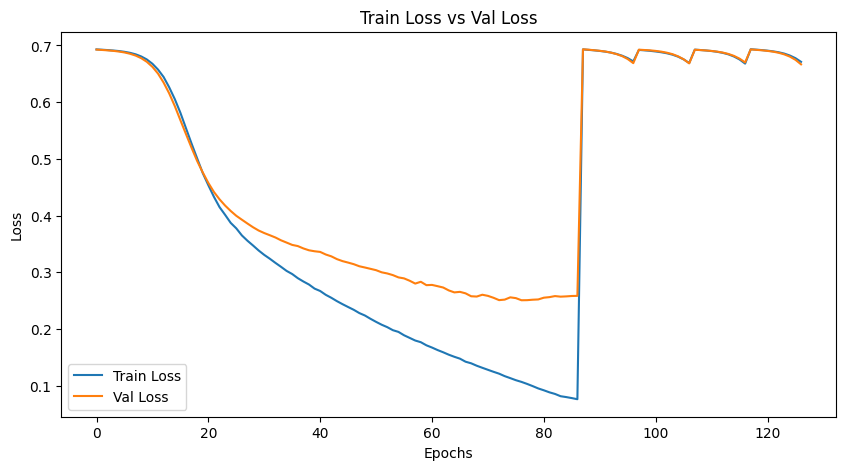

In [102]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [90]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['accuracy', 'f1', 'recall', 'roc_auc']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_scabal_{scoring}.pkl"
    joblib.dump(best_model, model_path)

Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5397	0.1212
200	0.457	0.0758
300	0.1754	0.0758
400	0.2378	0.0758
500	0.0774	0.0909
600	0.0381	0.0455
700	0.0621	0.0758
800	0.0236	0.0606
900	0.1023	0.0606
1000	0.0409	0.0303
1100	0.0332	0.0303
1200	0.0011	0.0455
1300	0.0055	0.0303
1400	0.0146	0.0303
1500	0.0374	0.0455
1600	0.03	0.0455
1700	0.0103	0.0303
1800	0.0477	0.0455
1900	0.0074	0.0303
2000	0.0141	0.0455
2100	0.035	0.0303
2200	0.0499	0.0455
2300	0.0202	0.0455
2400	0.0035	0.0455
2500	0.0068	0.0455
BREAK. There is no improvment for 500 steps
Total training time: 61.6 seconds
Best step:  1000
Best Val Metric:  0.030303030303030304
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for accuracy: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation accuracy: 0.9155433646812956
Fitting 5 folds for each of 10 candidates, t

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6376	0.303
200	0.5502	0.2273
300	0.5878	0.197
400	0.177	0.1515
500	0.1766	0.1212
600	0.1028	0.0606
700	0.1181	0.0909
800	0.153	0.0909
900	0.1071	0.0909
1000	0.0699	0.0909
1100	0.1932	0.0303
1200	0.1425	0.0303
1300	0.0664	0.0303
1400	0.0871	0.0152
1500	0.1265	0.0303
1600	0.1331	0.0152
1700	0.0822	0.0152
1800	0.0682	0.0152
1900	0.0727	0.0152
2000	0.033	0.0758
2100	0.1426	0.0455
2200	0.107	0.0152
2300	0.2374	0.0
2400	0.1299	0.0303
2500	0.0203	0.0303
2600	0.1114	0.0303
2700	0.1319	0.0152
2800	0.0772	0.0152
BREAK. There is no improvment for 500 steps
Total training time: 48.7 seconds
Best step:  2300
Best Val Metric:  0.0
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation f1: 0.8989183159062677
Fitting 5 folds for e

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5757	0.197
200	0.3246	0.1212
300	0.2725	0.1061
400	0.3772	0.0909
500	0.0783	0.0455
600	0.1312	0.0455
700	0.1329	0.0455
800	0.0375	0.0606
900	0.0577	0.0606
1000	0.0473	0.0606
1100	0.0645	0.0606
1200	0.0993	0.0606
1300	0.0496	0.0455
1400	0.0261	0.0606
1500	0.0135	0.0455
1600	0.0454	0.0303
1700	0.0381	0.0455
1800	0.0682	0.0606
1900	0.0384	0.0455
2000	0.0246	0.0455
2100	0.014	0.0455
2200	0.0105	0.0303
2300	0.0037	0.0303
2400	0.0419	0.0455
2500	0.0013	0.0455
BREAK. There is no improvment for 500 steps
Total training time: 66.4 seconds
Best step:  1600
Best Val Metric:  0.030303030303030304
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for recall: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation recall: 0.9150350572301793
Fitting 5 folds for each of 10 candidates, tot

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Entrenando con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.6199	0.1515
200	0.3942	0.1061
300	0.1884	0.0606
400	0.1971	0.0606
500	0.1797	0.0606
600	0.0605	0.0606
700	0.1783	0.0606
800	0.171	0.0909
900	0.1704	0.0606
1000	0.0748	0.0606
1100	0.0497	0.0606
1200	0.0444	0.0152
1300	0.0481	0.0303
1400	0.064	0.0303
1500	0.0644	0.0152
1600	0.0635	0.0303
1700	0.0341	0.0303
1800	0.0981	0.0152
1900	0.1004	0.0
2000	0.0942	0.0
2100	0.0673	0.0455
2200	0.0352	0.0303
2300	0.0926	0.0455
2400	0.0669	0.0303
2500	0.1205	0.0303
BREAK. There is no improvment for 500 steps
Total training time: 64.4 seconds
Best step:  1900
Best Val Metric:  0.0
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for roc_auc: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps

In [103]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\superior\\bal\\SCALER_BAL")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 100,
    'num_layers': 2,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}



# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


Using device: cuda


Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (535) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6087	0.1698
200	0.6293	0.1509
300	0.2415	0.1132
400	0.3639	0.1321
500	0.1171	0.1132
600	0.0475	0.0755
700	0.6282	0.0755
800	0.094	0.0755
900	0.0734	0.0755
1000	0.1206	0.0755
1100	0.0629	0.0755
1200	0.1009	0.0755
1300	0.0467	0.0755
1400	0.0226	0.0755
1500	0.068	0.0943
1600	0.0552	0.0755
1700	0.017	0.1132
1800	0.1269	0.0943
1900	0.0541	0.0755
2000	0.087	0.0755
2100	0.0301	0.0755
2200	0.0955	0.0943
2300	0.0031	0.0943
2400	0.2333	0.0755
2500	0.4033	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 47.5 seconds
Best step:  600
Best Val Metric:  0.07547169811320754
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 89.77272727272727%, F1-score: 89.76876065111358%, Test accuracy: 87.62886597938144%, Test F1-score: 87.47299625365747%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001,

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.6079	0.1321
200	0.3026	0.0943
300	0.6168	0.0566
400	0.2186	0.0566
500	0.1948	0.0566
600	0.2201	0.0755
700	0.0998	0.1132
800	0.053	0.1132
900	0.0479	0.1132
1000	0.0525	0.1321
1100	0.0814	0.1132
1200	0.0716	0.0943
1300	0.1308	0.1132
1400	0.0278	0.0943
1500	0.0213	0.0755
1600	0.0149	0.0943
1700	0.0019	0.0755
1800	0.1468	0.0943
1900	0.0087	0.1321
2000	0.0028	0.0566
2100	0.1176	0.0566
2200	0.1226	0.0943
2300	0.2416	0.0943
2400	0.0335	0.0943
2500	0.0325	0.0943
BREAK. There is no improvment for 500 steps
Total training time: 49.1 seconds
Best step:  300
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 79.3103448275862%, F1-score: 79.23330887747616%, Test accuracy: 83.50515463917526%, Test F1-score: 83.57546514795968%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.00

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5168	0.2264
200	0.4644	0.1698
300	0.2008	0.1321
400	0.0623	0.0943
500	0.2183	0.0943
600	0.165	0.1132
700	0.2734	0.1321
800	0.0272	0.0566
900	0.287	0.0566
1000	0.0344	0.0943
1100	0.0165	0.0566
1200	0.0788	0.0566
1300	0.1765	0.0566
1400	0.0016	0.0566
1500	0.0392	0.0566
1600	0.1469	0.0566
1700	0.2819	0.0566
1800	0.0104	0.0566
1900	0.0242	0.0566
2000	0.0652	0.0566
2100	0.3592	0.0755
2200	0.0368	0.0755
2300	0.0032	0.0566
2400	0.0767	0.0377
2500	0.0732	0.0377
2600	0.0416	0.0377
2700	0.0787	0.0377
2800	0.001	0.0377
2900	0.1008	0.0377
BREAK. There is no improvment for 500 steps
Total training time: 56.1 seconds
Best step:  2400
Best Val Metric:  0.03773584905660377
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 91.95402298850574%, F1-score: 91.93913287903305%, Test accuracy: 86.5979381443299%, Test F1-score: 86.52765528962956%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6314	0.2273
200	0.5765	0.197
300	0.4905	0.1667
400	0.3981	0.1818
500	0.2333	0.1515
600	0.3116	0.1364
700	0.2857	0.0606
800	0.1518	0.0606
900	0.1128	0.0455
1000	0.1971	0.0303
1100	0.1067	0.0455
1200	0.0279	0.0606
1300	0.0906	0.0455
1400	0.0907	0.0606
1500	0.0469	0.0303
1600	0.1404	0.0303
1700	0.0511	0.0455
1800	0.015	0.0303
1900	0.06	0.0152
2000	0.0791	0.0152
2100	0.0539	0.0
2200	0.0703	0.0
2300	0.1001	0.0152
2400	0.1104	0.0
2500	0.0581	0.0
2600	0.0351	0.0
BREAK. There is no improvment for 500 steps
Total training time: 51.6 seconds
Best step:  2100
Best Val Metric:  0.0
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\superior\bal\SCALER_BAL\best_model_fold_5.pth


In [104]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 87.89 ± 4.42%
F1-score: 87.86 ± 4.44%
Precisión (Precision): 88.35 ± 4.63%
Recall: 87.89 ± 4.42%

Métricas del Conjunto de Prueba:
Precisión: 86.39 ± 2.20%
F1-score: 86.35 ± 2.14%
Precisión (Precision): 86.78 ± 1.99%
Recall: 86.39 ± 2.20%


# BALANCED PCA_SCALER

In [105]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Train_superior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Test_superior.pkl')

In [106]:
smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

In [107]:
scaler = StandardScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train_resampled_s)
X_test_scaler = scaler.transform(X_test)

In [108]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_scaler)
X_train_pca= pca.transform(X_train_scaler)
X_test_pca=pca.transform(X_test_scaler)

In [109]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [110]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [111]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac sup\\scale_pca__bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")


Fold 1


 45%|████▌     | 5/11 [00:00<00:00, 44.98it/s, accuracy=0.469, loss=0.693, lr=0.0001]

100%|██████████| 11/11 [00:00<00:00, 38.51it/s, accuracy=0.467, loss=0.693, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac sup\scale_pca__bal\best_model.pth con val_loss: 0.692666212717692
Epoch 1, Train Loss: 0.6929770274595781, Val Loss: 0.692666212717692, Val Accuracy: 0.5


100%|██████████| 11/11 [00:00<00:00, 46.82it/s, accuracy=0.6, loss=0.692, lr=0.0001]  


...

Epoch 8, Train Loss: 0.6845772591504183, Val Loss: 0.6862262090047201, Val Accuracy: 0.45561594764391583


100%|██████████| 11/11 [00:00<00:00, 47.07it/s, accuracy=0.355, loss=0.684, lr=0.0001]


Epoch 9, Train Loss: 0.6816289641640403, Val Loss: 0.6838001012802124, Val Accuracy: 0.45561594764391583


100%|██████████| 11/11 [00:00<00:00, 45.12it/s, accuracy=0.645, loss=0.676, lr=0.0001]


Epoch 10, Train Loss: 0.677507069977847, Val Loss: 0.6804624597231547, Val Accuracy: 0.45561594764391583
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 82.4742268041237%, F1-score: 82.49692613260193%, Precision: 82.53727234786933%, Recall: 82.4742268041237%


In [112]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 79.39 ± 8.71%
F1-score: 78.98 ± 9.41%
Precisión (Precision): 81.30 ± 7.06%
Recall: 79.39 ± 8.71%

Métricas del Conjunto de Prueba:
Precisión: 79.38 ± 3.75%
F1-score: 79.19 ± 3.96%
Precisión (Precision): 80.94 ± 3.19%
Recall: 79.38 ± 3.75%


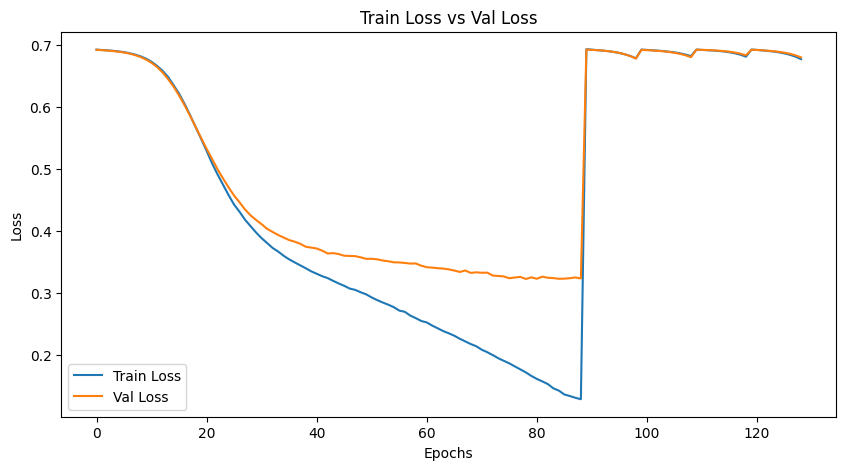

In [113]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [114]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\superior\\bal\\scaler_pca_bal")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 100,
    'num_layers': 2,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}



# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (535) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.8003	0.5283
200	0.4786	0.4151
300	0.4409	0.3208
400	0.1453	0.1698
500	0.1991	0.1132
600	0.2247	0.1132
700	0.2576	0.0943
800	0.4053	0.1132
900	0.1923	0.1132
1000	0.0899	0.1132
1100	0.3053	0.0943
1200	0.0955	0.1132
1300	0.237	0.1321
1400	0.2275	0.1321
1500	0.0978	0.1321
1600	0.0298	0.1321
1700	0.052	0.1132
1800	0.0616	0.0943
1900	0.02	0.0943
2000	0.0141	0.0943
2100	0.0119	0.0943
2200	0.1537	0.1321
2300	0.0653	0.1321
2400	0.0757	0.1321
2500	0.2859	0.1509
BREAK. There is no improvment for 500 steps
Total training time: 47.8 seconds
Best step:  700
Best Val Metric:  0.09433962264150944
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 93.18181818181817%, F1-score: 93.16058876256075%, Test accuracy: 90.72164948453609%, Test F1-score: 90.75155071081859%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001,

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5974	0.2453
200	0.6915	0.2453
300	0.4658	0.1509
400	0.1995	0.1698
500	0.1022	0.0943
600	0.2097	0.0755
700	0.1323	0.0943
800	0.1528	0.0566
900	0.1142	0.0755
1000	0.1322	0.0566
1100	0.2415	0.0755
1200	0.057	0.0566
1300	0.1935	0.0566
1400	0.5064	0.0377
1500	0.3811	0.0755
1600	0.034	0.0943
1700	0.2332	0.0943
1800	0.0544	0.0755
1900	0.1203	0.1132
2000	0.1452	0.1132
2100	0.1994	0.1509
2200	0.2466	0.1132
2300	0.2804	0.1321
2400	0.0856	0.1321
2500	0.2618	0.1321
BREAK. There is no improvment for 500 steps
Total training time: 52.5 seconds
Best step:  1400
Best Val Metric:  0.03773584905660377
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 89.77272727272727%, F1-score: 89.65611852935797%, Test accuracy: 86.5979381443299%, Test F1-score: 86.61529645434264%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.00

...

Steps	Train Err	Val Metric (error_rate)
100	0.7532	0.2642
200	0.6902	0.1887
300	0.4003	0.1321
400	0.2947	0.0943
500	0.3352	0.0566
600	0.1729	0.0566
700	0.5572	0.0566
800	0.2434	0.0377
900	0.1128	0.0377
1000	0.0194	0.0189
1100	0.0859	0.0377
1200	0.0641	0.0566
1300	0.033	0.0566
1400	0.0469	0.0566
1500	0.1262	0.0566
1600	0.1214	0.0566
1700	0.0172	0.0566
1800	0.0499	0.0566
1900	0.0723	0.0566
2000	0.1766	0.0377
2100	0.1525	0.0377
2200	0.2597	0.0377
2300	0.0015	0.0377
2400	0.0126	0.0566
2500	0.0168	0.0566
BREAK. There is no improvment for 500 steps
Total training time: 52.4 seconds
Best step:  1000
Best Val Metric:  0.018867924528301886
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 86.20689655172413%, F1-score: 86.15553925165077%, Test accuracy: 88.65979381443299%, Test F1-score: 88.69633975766716%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5117	0.3774
200	0.6264	0.2075
300	0.4062	0.1887
400	0.338	0.1132
500	0.2788	0.0943
600	0.1377	0.0755
700	0.1538	0.0943
800	0.1962	0.0755
900	0.2029	0.0943
1000	0.2429	0.0755
1100	0.0256	0.0943
1200	0.263	0.1132
1300	0.0533	0.0943
1400	0.2526	0.0755
1500	0.1267	0.0943
1600	0.0673	0.0943
1700	0.0922	0.1132
1800	0.1285	0.1132
1900	0.1501	0.1132
2000	0.1204	0.0943
2100	0.2553	0.1132
2200	0.2725	0.1132
2300	0.0274	0.0943
2400	0.0178	0.0943
2500	0.1483	0.0943
BREAK. There is no improvment for 500 steps
Total training time: 49.7 seconds
Best step:  600
Best Val Metric:  0.07547169811320754
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 90.80459770114942%, F1-score: 90.80945785035601%, Test accuracy: 89.69072164948454%, Test F1-score: 89.73050874431928%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.754	0.2727
200	0.4995	0.1061
300	0.43	0.1061
400	0.4611	0.0758
500	0.2545	0.0909
600	0.5661	0.1061
700	0.2958	0.1061
800	0.3232	0.1061
900	0.1078	0.0909
1000	0.1595	0.0909
1100	0.3206	0.0909
1200	0.1051	0.0606
1300	0.2235	0.0606
1400	0.1067	0.0758
1500	0.2119	0.0758
1600	0.1853	0.0758
1700	0.257	0.0455
1800	0.2595	0.0606
1900	0.206	0.0758
2000	0.2298	0.1212
2100	0.1248	0.0909
2200	0.185	0.1061
2300	0.1337	0.1364
2400	0.2369	0.1212
2500	0.0848	0.1212
BREAK. There is no improvment for 500 steps
Total training time: 50.4 seconds
Best step:  1700
Best Val Metric:  0.045454545454545456
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\superior\bal\scaler_pca_bal\best_model_fold_1.pth


In [115]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 90.18 ± 2.28%
F1-score: 90.16 ± 2.30%
Precisión (Precision): 90.66 ± 2.36%
Recall: 90.18 ± 2.28%

Métricas del Conjunto de Prueba:
Precisión: 89.48 ± 1.77%
F1-score: 89.51 ± 1.77%
Precisión (Precision): 89.69 ± 1.81%
Recall: 89.48 ± 1.77%


In [114]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['f1']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_scapcabal_{scoring}.pkl"
    joblib.dump(best_model, model_path)

Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6945	0.3939
200	0.676	0.2273
300	0.5074	0.1364
400	0.3719	0.1061
500	0.163	0.1212
600	0.2544	0.1364
700	0.1532	0.1212
800	0.1458	0.1212
900	0.2594	0.1212
1000	0.2379	0.1212
1100	0.3965	0.1212
1200	0.3103	0.1061
1300	0.0683	0.0909
1400	0.2033	0.1364
1500	0.1377	0.1061
1600	0.1288	0.1212
1700	0.2286	0.1212
1800	0.1508	0.0758
1900	0.1067	0.0758
2000	0.1006	0.1061
2100	0.1142	0.0909
2200	0.3433	0.1061
2300	0.0802	0.1061
2400	0.2947	0.0758
2500	0.1099	0.0758
BREAK. There is no improvment for 500 steps
Total training time: 43.7 seconds
Best step:  1800
Best Val Metric:  0.07575757575757576
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation f1: 0.8948930818810338


# Balanced Robustscaler

In [116]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Train_superior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Test_superior.pkl')

In [117]:
smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

In [118]:
scaler = RobustScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train_resampled_s)
X_test_scaler = scaler.transform(X_test)

In [119]:
X_train_unbalance= torch.tensor(X_train_scaler, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_scaler, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)


## KAN

In [120]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [121]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Roscaler_bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")




Fold 1


 36%|███▋      | 4/11 [00:00<00:00, 39.21it/s, accuracy=0.281, loss=0.695, lr=0.0001]

100%|██████████| 11/11 [00:00<00:00, 33.80it/s, accuracy=0.567, loss=0.692, lr=0.0001]
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac sup\Roscaler_bal\best_model.pth con val_loss: 0.6929873625437418
Epoch 1, Train Loss: 0.6933201117949053, Val Loss: 0.6929873625437418, Val Accuracy: 0.5


100%|██████████| 11/11 [00:00<00:00, 43.64it/s, accuracy=0.633, loss=0.692, lr=0.0001]
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

Epoch 8, Train Loss: 0.68601670590314, Val Loss: 0.6848825216293335, Val Accuracy: 0.45561594764391583


100%|██████████| 11/11 [00:00<00:00, 32.37it/s, accuracy=0.419, loss=0.679, lr=0.0001]


Epoch 9, Train Loss: 0.6829253164204684, Val Loss: 0.6812223196029663, Val Accuracy: 0.45561594764391583


100%|██████████| 11/11 [00:00<00:00, 39.27it/s, accuracy=0.71, loss=0.675, lr=0.0001]


Epoch 10, Train Loss: 0.6784704652699557, Val Loss: 0.6757830182711283, Val Accuracy: 0.45561594764391583
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 80.41237113402062%, F1-score: 80.4581901489118%, Precision: 82.59093561563897%, Recall: 80.41237113402062%


In [122]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 79.80 ± 12.36%
F1-score: 78.31 ± 15.73%
Precisión (Precision): 82.05 ± 11.63%
Recall: 79.80 ± 12.36%

Métricas del Conjunto de Prueba:
Precisión: 79.38 ± 6.49%
F1-score: 79.00 ± 7.18%
Precisión (Precision): 82.62 ± 2.62%
Recall: 79.38 ± 6.49%


## NODE_GAM

In [123]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\superior\\bal\\roscaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 200,
    'num_layers': 2,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (535) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6699	0.1887
200	0.4125	0.1509
300	0.379	0.1321
400	0.1661	0.0943
500	0.0771	0.0943
600	0.025	0.1132
700	0.0636	0.0943
800	0.1435	0.0943
900	0.1163	0.0943
1000	0.0356	0.0943
1100	0.0373	0.1132
1200	0.0763	0.0943
1300	0.0226	0.0943
1400	0.0417	0.0943
1500	0.0982	0.0943
1600	0.0105	0.0943
1700	0.0258	0.0755
1800	0.0285	0.0755
1900	0.017	0.0755
2000	0.0144	0.0943
2100	0.2504	0.0943
2200	0.0215	0.0943
2300	0.0396	0.0755
2400	0.1015	0.0755
2500	0.1403	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 52.0 seconds
Best step:  1700
Best Val Metric:  0.07547169811320754
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 93.18181818181817%, F1-score: 93.18181818181817%, Test accuracy: 87.62886597938144%, Test F1-score: 87.53662506782419%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.00

...

Steps	Train Err	Val Metric (error_rate)
100	0.694	0.1509
200	0.1204	0.0755
300	0.1572	0.0943
400	0.1397	0.0943
500	0.1852	0.1132
600	0.1055	0.0755
700	0.0482	0.0755
800	0.0873	0.0755
900	0.015	0.1132
1000	0.0098	0.1132
1100	0.0414	0.0755
1200	0.0293	0.1132
1300	0.0906	0.0943
1400	0.0152	0.1132
1500	0.008	0.1132
1600	0.01	0.1132
1700	0.0104	0.1132
1800	0.0147	0.1132
1900	0.0223	0.1321
2000	0.4075	0.1132
2100	0.052	0.0943
2200	0.038	0.0943
2300	0.0217	0.0943
2400	0.0088	0.0943
2500	0.0054	0.0943
BREAK. There is no improvment for 500 steps
Total training time: 53.5 seconds
Best step:  200
Best Val Metric:  0.07547169811320754
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 77.01149425287356%, F1-score: 76.73987925478721%, Test accuracy: 82.4742268041237%, Test F1-score: 82.54924348982036%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'la

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5947	0.2264
200	0.285	0.1698
300	0.2127	0.1509
400	0.1837	0.1509
500	0.1502	0.1509
600	0.2593	0.1509
700	0.2276	0.1132
800	0.2011	0.1321
900	0.3224	0.0943
1000	0.0807	0.1132
1100	0.0857	0.1132
1200	0.0783	0.0943
1300	0.0833	0.0943
1400	0.0201	0.1132
1500	0.0301	0.1509
1600	0.0025	0.1132
1700	0.0918	0.1132
1800	0.0282	0.1132
1900	0.2729	0.0755
2000	0.0013	0.1132
2100	0.0318	0.1132
2200	0.0015	0.1132
2300	0.0034	0.1132
2400	0.1435	0.1132
2500	0.0362	0.1132
BREAK. There is no improvment for 500 steps
Total training time: 55.5 seconds
Best step:  1900
Best Val Metric:  0.07547169811320754
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 90.80459770114942%, F1-score: 90.77540594781975%, Test accuracy: 89.69072164948454%, Test F1-score: 89.61385422318683%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6611	0.1818
200	0.5824	0.1515
300	0.3796	0.1515
400	0.1774	0.0909
500	0.1922	0.1212
600	0.0652	0.1061
700	0.107	0.1061
800	0.1266	0.1061
900	0.1245	0.1061
1000	0.0629	0.1061
1100	0.0907	0.0606
1200	0.1337	0.0303
1300	0.0783	0.0303
1400	0.0962	0.0152
1500	0.0117	0.0303
1600	0.0741	0.0455
1700	0.0763	0.0303
1800	0.0372	0.0303
1900	0.0469	0.0152
2000	0.2725	0.0152
2100	0.1516	0.0152
2200	0.0341	0.0303
2300	0.02	0.0455
2400	0.0742	0.0152
2500	0.0571	0.0152
BREAK. There is no improvment for 500 steps
Total training time: 52.1 seconds
Best step:  1400
Best Val Metric:  0.015151515151515152
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\superior\bal\roscaler\best_model_fold_2.pth


In [124]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 89.25 ± 6.26%
F1-score: 89.19 ± 6.37%
Precisión (Precision): 89.75 ± 6.06%
Recall: 89.25 ± 6.26%

Métricas del Conjunto de Prueba:
Precisión: 87.22 ± 2.49%
F1-score: 87.18 ± 2.44%
Precisión (Precision): 87.41 ± 2.31%
Recall: 87.22 ± 2.49%


# BALANCED PCA_roSCALER

In [125]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Train_superior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Test_superior.pkl')

In [126]:
smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

In [127]:
scaler = RobustScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train_resampled_s)
X_test_scaler = scaler.transform(X_test)

In [128]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_scaler)
X_train_pca= pca.transform(X_train_scaler)
X_test_pca=pca.transform(X_test_scaler)

In [129]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [130]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [131]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac sup\\pca_roscaler_bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")
   

Fold 1


100%|██████████| 11/11 [00:00<00:00, 32.53it/s, accuracy=0.433, loss=0.693, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac sup\pca_roscaler_bal\best_model.pth con val_loss: 0.6933224598566691
Epoch 1, Train Loss: 0.6934383294799111, Val Loss: 0.6933224598566691, Val Accuracy: 0.5


100%|██████████| 11/11 [00:00<00:00, 41.70it/s, accuracy=0.367, loss=0.693, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac sup\pca_roscaler_bal\best_model.pth con val_loss: 0.6926957964897156
Epoch 2, Train Loss: 0.6928386796604503, Val Loss: 0.6926957964897156, Val Accuracy: 0.5


...

Epoch 8, Train Loss: 0.6856266260147095, Val Loss: 0.6840721567471822, Val Accuracy: 0.45561594764391583


100%|██████████| 11/11 [00:00<00:00, 44.64it/s, accuracy=0.516, loss=0.679, lr=0.0001]


Epoch 9, Train Loss: 0.6828985105861317, Val Loss: 0.6809724569320679, Val Accuracy: 0.45561594764391583


100%|██████████| 11/11 [00:00<00:00, 42.87it/s, accuracy=0.516, loss=0.684, lr=0.0001]


Epoch 10, Train Loss: 0.6795625253157183, Val Loss: 0.6765607198079427, Val Accuracy: 0.45561594764391583
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 85.56701030927834%, F1-score: 85.29663316074564%, Precision: 86.27932272565383%, Recall: 85.56701030927834%


In [132]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 75.17 ± 11.22%
F1-score: 73.89 ± 14.09%
Precisión (Precision): 78.98 ± 8.70%
Recall: 75.17 ± 11.22%

Métricas del Conjunto de Prueba:
Precisión: 83.51 ± 3.97%
F1-score: 83.14 ± 4.22%
Precisión (Precision): 85.09 ± 2.96%
Recall: 83.51 ± 3.97%


## NODE_GAM

In [133]:

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\superior\\bal\\PCA_roscaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 200,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.4,
    'early_stopping_steps': 500,
    'depth': 4
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")



c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (535) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}
Steps	Train Err	Val Metric (error_rate)
100	0.7357	0.3019
200	0.2979	0.1132
300	0.1435	0.0755
400	0.0625	0.0943
500	0.0776	0.0755
600	0.5967	0.0566
700	0.0319	0.0566
800	0.0354	0.0755
900	0.1718	0.0755
1000	0.1261	0.0755
1100	0.0267	0.1132
1200	0.0213	0.1132
1300	0.0461	0.0755
1400	0.1439	0.0755
1500	0.0597	0.0755
1600	0.0646	0.0755
1700	0.0185	0.0377
1800	0.0077	0.0566
1900	0.0198	0.0566
2000	0.0673	0.0755
2100	0.362	0.0755
2200	0.1164	0.0943
2300	0.1448	0.1132
2400	0.0374	0.0943
2500	0.0283	0.0943
BREAK. There is no improvment for 500 steps
Total training time: 74.6 seconds
Best step:  1700
Best Val Metric:  0.03773584905660377
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 92.04545454545455%, F1-score: 92.

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5998	0.4906
200	0.5472	0.1509
300	0.3937	0.1132
400	0.2808	0.0943
500	0.1454	0.0755
600	0.0852	0.0566
700	0.0897	0.0755
800	0.071	0.0566
900	0.14	0.0189
1000	0.0146	0.0189
1100	0.0032	0.0189
1200	0.0246	0.0755
1300	0.034	0.0755
1400	0.0368	0.0943
1500	0.0997	0.0943
1600	0.0165	0.0755
1700	0.0121	0.0755
1800	0.1068	0.0755
1900	0.0122	0.0377
2000	0.0686	0.0755
2100	0.0444	0.0377
2200	0.082	0.0943
2300	0.0205	0.0943
2400	0.009	0.0755
2500	0.0791	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 74.9 seconds
Best step:  900
Best Val Metric:  0.018867924528301886
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 90.9090909090909%, F1-score: 90.83139083139083%, Test accuracy: 85.56701030927834%, Test F1-score: 85.622712242047%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'la

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.6049	0.3019
200	0.4547	0.1132
300	0.2505	0.1132
400	0.2357	0.0755
500	0.1052	0.0943
600	0.1714	0.0943
700	0.0793	0.1132
800	0.138	0.0755
900	0.1075	0.0943
1000	0.0958	0.0755
1100	0.0099	0.0566
1200	0.2802	0.0566
1300	0.0631	0.0755
1400	0.1239	0.0755
1500	0.0065	0.0566
1600	0.035	0.0566
1700	0.0411	0.0566
1800	0.0053	0.0566
1900	0.0597	0.0566
2000	0.1693	0.0566
2100	0.0386	0.0566
2200	0.0237	0.0566
2300	0.0713	0.0566
2400	0.1737	0.0566
2500	0.0028	0.0566
BREAK. There is no improvment for 500 steps
Total training time: 72.7 seconds
Best step:  1100
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 85.0574712643678%, F1-score: 85.06142170157484%, Test accuracy: 84.5360824742268%, Test F1-score: 84.58591785136433%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7517	0.2642
200	0.5212	0.1698
300	0.7016	0.1132
400	0.0677	0.0755
500	0.1589	0.0755
600	0.0449	0.0566
700	0.0956	0.0755
800	0.0492	0.0755
900	0.017	0.0943
1000	0.1324	0.0755
1100	0.0868	0.0755
1200	0.1388	0.0755
1300	0.0286	0.0755
1400	0.1511	0.0755
1500	0.0292	0.0755
1600	0.0618	0.0755
1700	0.0661	0.1132
1800	0.002	0.1132
1900	0.1072	0.1132
2000	0.1131	0.0943
2100	0.0239	0.0943
2200	0.0111	0.0755
2300	0.0146	0.0943
2400	0.0704	0.0755
2500	0.1221	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 73.5 seconds
Best step:  600
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 86.20689655172413%, F1-score: 86.19596121600932%, Test accuracy: 84.5360824742268%, Test F1-score: 84.55611129347227%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5977	0.3182
200	0.4909	0.2424
300	0.3121	0.1515
400	0.2437	0.1364
500	0.4207	0.0909
600	0.1523	0.1061
700	0.2266	0.0455
800	0.207	0.0455
900	0.0435	0.0455
1000	0.1802	0.0455
1100	0.1761	0.0455
1200	0.2299	0.0455
1300	0.0457	0.0606
1400	0.0867	0.0455
1500	0.1286	0.0455
1600	0.056	0.0303
1700	0.0426	0.0455
1800	0.0817	0.0606
1900	0.0816	0.0606
2000	0.0734	0.0606
2100	0.0467	0.0455
2200	0.1502	0.0455
2300	0.0132	0.0606
2400	0.022	0.0606
2500	0.0463	0.0606
BREAK. There is no improvment for 500 steps
Total training time: 70.2 seconds
Best step:  1600
Best Val Metric:  0.030303030303030304
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\superior\bal\PCA_roscaler\best_model_fold_1.pth


In [134]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 88.34 ± 2.70%
F1-score: 88.35 ± 2.67%
Precisión (Precision): 88.98 ± 2.59%
Recall: 88.34 ± 2.70%

Métricas del Conjunto de Prueba:
Precisión: 84.12 ± 1.40%
F1-score: 84.16 ± 1.40%
Precisión (Precision): 84.31 ± 1.45%
Recall: 84.12 ± 1.40%


# Balanced min_maxtscaler

In [61]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Train_superior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Test_superior.pkl')

smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

scaler = MinMaxScaler().fit(X_train_resampled_s)

X_train_scaler = scaler.transform(X_train_resampled_s)
X_test_scaler = scaler.transform(X_test)

X_train_unbalance= torch.tensor(X_train_scaler, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_scaler, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [62]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [63]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac sup\\MinMaxcaler_bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")




Fold 1


100%|██████████| 11/11 [00:00<00:00, 39.27it/s, accuracy=0.533, loss=0.693, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac sup\MinMaxcaler_bal\best_model.pth con val_loss: 0.692959209283193
Epoch 1, Train Loss: 0.6930746598677202, Val Loss: 0.692959209283193, Val Accuracy: 0.5


100%|██████████| 11/11 [00:00<00:00, 52.37it/s, accuracy=0.467, loss=0.693, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac sup\MinMaxcaler_bal\best_model.pth con val_loss: 0.6928466359774271
Epoch 2, Train Loss: 0.6929141553965482, Val Loss: 0.6928466359774271, Val Accuracy: 0.5


...

Epoch 8, Train Loss: 0.6916840239004656, Val Loss: 0.6920073628425598, Val Accuracy: 0.45561594764391583


100%|██████████| 11/11 [00:00<00:00, 44.34it/s, accuracy=0.613, loss=0.69, lr=0.0001]


Epoch 9, Train Loss: 0.6911783868616278, Val Loss: 0.6914150714874268, Val Accuracy: 0.45561594764391583


100%|██████████| 11/11 [00:00<00:00, 46.49it/s, accuracy=0.613, loss=0.691, lr=0.0001]


Epoch 10, Train Loss: 0.6904923482374712, Val Loss: 0.6906044880549113, Val Accuracy: 0.45561594764391583
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 78.35051546391753%, F1-score: 77.29627969520394%, Precision: 80.6087383406971%, Recall: 78.35051546391753%


In [64]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 80.90 ± 17.69%
F1-score: 78.20 ± 23.00%
Precisión (Precision): 79.73 ± 23.83%
Recall: 80.90 ± 17.69%

Métricas del Conjunto de Prueba:
Precisión: 69.69 ± 17.18%
F1-score: 62.93 ± 24.83%
Precisión (Precision): 60.69 ± 29.30%
Recall: 69.69 ± 17.18%


## NODE_GAM

In [65]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\superior\\bal\\MinMaxcaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 300,
    'num_layers': 2,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 4
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (535) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.553	0.1887
200	0.426	0.1698
300	0.2015	0.0943
400	0.2787	0.0943
500	0.0084	0.0755
600	0.027	0.0755
700	0.041	0.0943
800	0.076	0.0943
900	0.024	0.0943
1000	0.0682	0.0943
1100	0.0149	0.0943
1200	0.0326	0.1132
1300	0.0891	0.0755
1400	0.0088	0.0755
1500	0.0028	0.0755
1600	0.0136	0.0943
1700	0.0227	0.0755
1800	0.0027	0.0943
1900	0.0021	0.0755
2000	0.0069	0.0755
2100	0.009	0.0755
2200	0.0297	0.0755
2300	0.0009	0.0755
2400	0.0001	0.0755
2500	0.0126	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 45.7 seconds
Best step:  500
Best Val Metric:  0.07547169811320754
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 89.77272727272727%, F1-score: 89.76876474939242%, Test accuracy: 88.65979381443299%, Test F1-score: 88.674481615213%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'las

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.5855	0.1698
200	0.341	0.0755
300	0.0957	0.0943
400	0.326	0.0943
500	0.0568	0.1132
600	0.0388	0.1132
700	0.0564	0.1132
800	0.0192	0.1132
900	0.0141	0.1132
1000	0.015	0.1132
1100	0.021	0.1132
1200	0.0037	0.1132
1300	0.0525	0.1132
1400	0.0031	0.1132
1500	0.0045	0.1132
1600	0.0031	0.1132
1700	0.0018	0.1132
1800	0.0151	0.1132
1900	0.0038	0.1132
2000	0.0053	0.1132
2100	0.0193	0.1132
2200	0.0091	0.1132
2300	0.0125	0.1132
2400	0.0077	0.1132
2500	0.0019	0.1132
BREAK. There is no improvment for 500 steps
Total training time: 42.7 seconds
Best step:  200
Best Val Metric:  0.07547169811320754
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 81.60919540229885%, F1-score: 81.60919540229885%, Test accuracy: 85.56701030927834%, Test F1-score: 85.60119697736577%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001,

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.4314	0.2075
200	0.2881	0.1887
300	0.1434	0.1509
400	0.0956	0.1321
500	0.0583	0.1321
600	0.1923	0.1321
700	0.0381	0.1321
800	0.1147	0.1321
900	0.028	0.1321
1000	0.05	0.1321
1100	0.0358	0.1321
1200	0.128	0.1321
1300	0.0946	0.1132
1400	0.0061	0.1321
1500	0.0816	0.1132
1600	0.0497	0.1132
1700	0.0205	0.1132
1800	0.0094	0.0943
1900	0.0141	0.0943
2000	0.007	0.0755
2100	0.011	0.0755
2200	0.0505	0.0943
2300	0.0096	0.0943
2400	0.0271	0.0943
2500	0.0075	0.0943
BREAK. There is no improvment for 500 steps
Total training time: 42.9 seconds
Best step:  2000
Best Val Metric:  0.07547169811320754
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 91.95402298850574%, F1-score: 91.93913287903305%, Test accuracy: 86.5979381443299%, Test F1-score: 86.57757247994485%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5833	0.1818
200	0.4156	0.1061
300	0.2331	0.0758
400	0.1461	0.0606
500	0.0752	0.0909
600	0.1458	0.0758
700	0.0876	0.0455
800	0.0332	0.0606
900	0.0448	0.0455
1000	0.0483	0.0152
1100	0.0502	0.0303
1200	0.0562	0.0303
1300	0.0285	0.0455
1400	0.0747	0.0455
1500	0.0314	0.0455
1600	0.0208	0.0455
1700	0.0207	0.0455
1800	0.0235	0.0303
1900	0.0261	0.0303
2000	0.0389	0.0303
2100	0.0043	0.0152
2200	0.0179	0.0303
2300	0.0249	0.0455
2400	0.0041	0.0303
2500	0.0051	0.0303
BREAK. There is no improvment for 500 steps
Total training time: 43.7 seconds
Best step:  1000
Best Val Metric:  0.015151515151515152
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\superior\bal\MinMaxcaler\best_model_fold_5.pth


In [66]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 87.67 ± 3.45%
F1-score: 87.64 ± 3.45%
Precisión (Precision): 88.25 ± 3.76%
Recall: 87.67 ± 3.45%

Métricas del Conjunto de Prueba:
Precisión: 87.01 ± 1.05%
F1-score: 87.01 ± 1.03%
Precisión (Precision): 87.12 ± 1.03%
Recall: 87.01 ± 1.05%


# unBALANCED PCA_minmaxSCALER

In [67]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Train_superior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Test_superior.pkl')

smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

scaler = MinMaxScaler().fit(X_train_resampled_s)

X_train_scaler = scaler.transform(X_train_resampled_s)
X_test_scaler = scaler.transform(X_test)


from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_scaler)
X_train_pca= pca.transform(X_train_scaler)
X_test_pca=pca.transform(X_test_scaler)

X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [68]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [69]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac sup\\pca_minmax_bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")
   

Fold 1


100%|██████████| 11/11 [00:00<00:00, 39.63it/s, accuracy=0.433, loss=0.693, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac sup\pca_minmax_bal\best_model.pth con val_loss: 0.6930960814158121
Epoch 1, Train Loss: 0.6931541128592058, Val Loss: 0.6930960814158121, Val Accuracy: 0.5


100%|██████████| 11/11 [00:00<00:00, 52.13it/s, accuracy=0.567, loss=0.693, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac sup\pca_minmax_bal\best_model.pth con val_loss: 0.6929900050163269
Epoch 2, Train Loss: 0.6930198723619635, Val Loss: 0.6929900050163269, Val Accuracy: 0.5


...

Epoch 8, Train Loss: 0.6913910941644148, Val Loss: 0.6918162306149801, Val Accuracy: 0.45561594764391583


100%|██████████| 11/11 [00:00<00:00, 41.98it/s, accuracy=0.613, loss=0.69, lr=0.0001]


Epoch 9, Train Loss: 0.6908256411552429, Val Loss: 0.691275417804718, Val Accuracy: 0.45561594764391583


100%|██████████| 11/11 [00:00<00:00, 46.31it/s, accuracy=0.452, loss=0.689, lr=0.0001]

Epoch 10, Train Loss: 0.6900706399570812, Val Loss: 0.6906392772992452, Val Accuracy: 0.45561594764391583
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 64.94845360824742%, F1-score: 57.16895761741122%, Precision: 78.33893200509672%, Recall: 64.94845360824742%


In [70]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 75.86 ± 19.25%
F1-score: 71.75 ± 25.85%
Precisión (Precision): 72.51 ± 27.92%
Recall: 75.86 ± 19.25%

Métricas del Conjunto de Prueba:
Precisión: 67.22 ± 17.12%
F1-score: 58.88 ± 23.99%
Precisión (Precision): 60.55 ± 29.39%
Recall: 67.22 ± 17.12%


## NODE_GAM

In [71]:

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\superior\\bal\\PCA_minmax")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 100,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 4
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")



c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (535) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}
Steps	Train Err	Val Metric (error_rate)
100	0.8234	0.283
200	0.398	0.1887
300	0.3042	0.1509
400	0.2284	0.0943
500	0.2084	0.1132
600	0.1486	0.0943
700	0.1399	0.0755
800	0.0925	0.0755
900	0.5317	0.0566
1000	0.193	0.0566
1100	0.1309	0.1132
1200	0.0499	0.0943
1300	0.0106	0.0943
1400	0.0658	0.0943
1500	0.2369	0.0943
1600	0.0616	0.1132
1700	0.0171	0.1132
1800	0.0261	0.0943
1900	0.065	0.0943
2000	0.208	0.1321
2100	0.0084	0.1132
2200	0.1955	0.1132
2300	0.03	0.1132
2400	0.0159	0.1132
2500	0.0991	0.1132
BREAK. There is no improvment for 500 steps
Total training time: 69.8 seconds
Best step:  900
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 89.77272727272727%, F1-score: 89.7528941

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6875	0.3396
200	0.4881	0.2453
300	0.3561	0.1321
400	0.141	0.0943
500	0.2612	0.0755
600	0.2956	0.0377
700	0.1825	0.0377
800	0.1925	0.0377
900	0.1915	0.0377
1000	0.2521	0.0755
1100	0.0675	0.0755
1200	0.3308	0.0566
1300	0.1123	0.0755
1400	0.0111	0.0943
1500	0.0514	0.0755
1600	0.196	0.0755
1700	0.0443	0.0943
1800	0.0669	0.0943
1900	0.0598	0.1132
2000	0.0055	0.1132
2100	0.0486	0.0755
2200	0.0528	0.0943
2300	0.2074	0.0943
2400	0.2198	0.0943
2500	0.0279	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 70.2 seconds
Best step:  600
Best Val Metric:  0.03773584905660377
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 88.63636363636364%, F1-score: 88.59420918244449%, Test accuracy: 80.41237113402062%, Test F1-score: 80.38260593222711%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.00

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.6374	0.2075
200	0.4999	0.1509
300	0.2339	0.0755
400	0.213	0.0755
500	0.053	0.0566
600	0.0662	0.0755
700	0.2131	0.0943
800	0.0609	0.0943
900	0.1729	0.0755
1000	0.1057	0.0943
1100	0.0647	0.0943
1200	0.0771	0.0755
1300	0.164	0.0943
1400	0.0493	0.0943
1500	0.012	0.0943
1600	0.0541	0.0943
1700	0.009	0.1132
1800	0.0153	0.1132
1900	0.2021	0.0943
2000	0.0924	0.1321
2100	0.0919	0.1321
2200	0.0182	0.1132
2300	0.0839	0.0755
2400	0.014	0.0755
2500	0.6093	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 70.1 seconds
Best step:  500
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 83.9080459770115%, F1-score: 83.88671517899587%, Test accuracy: 87.62886597938144%, Test F1-score: 87.62886597938144%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'l

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6882	0.3396
200	0.5136	0.2264
300	0.3211	0.1698
400	0.2349	0.1132
500	0.0497	0.0943
600	0.0795	0.0566
700	0.2256	0.0566
800	0.0733	0.0566
900	0.1126	0.0566
1000	0.0075	0.0755
1100	0.0427	0.0755
1200	0.0216	0.0755
1300	0.0816	0.0755
1400	0.0384	0.0566
1500	0.123	0.0566
1600	0.2455	0.0566
1700	0.1338	0.0377
1800	0.0064	0.0189
1900	0.0793	0.0566
2000	0.079	0.0377
2100	0.0081	0.0566
2200	0.288	0.0566
2300	0.0455	0.0566
2400	0.125	0.0566
2500	0.0129	0.0377
BREAK. There is no improvment for 500 steps
Total training time: 69.8 seconds
Best step:  1800
Best Val Metric:  0.018867924528301886
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 87.35632183908046%, F1-score: 87.29605804803145%, Test accuracy: 85.56701030927834%, Test F1-score: 85.3851622959337%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6353	0.3939
200	0.6049	0.1667
300	0.2546	0.0909
400	0.3646	0.0758
500	0.3556	0.0758
600	0.1495	0.0909
700	0.3412	0.0606
800	0.1412	0.0606
900	0.2239	0.0455
1000	0.1064	0.0758
1100	0.1053	0.0606
1200	0.087	0.0606
1300	0.106	0.0758
1400	0.1331	0.0606
1500	0.0848	0.0606
1600	0.1455	0.0606
1700	0.0891	0.0758
1800	0.2697	0.0758
1900	0.1241	0.0455
2000	0.1454	0.0606
2100	0.0547	0.0606
2200	0.1058	0.0455
2300	0.1065	0.0455
2400	0.1804	0.0606
2500	0.0974	0.0606
BREAK. There is no improvment for 500 steps
Total training time: 70.1 seconds
Best step:  900
Best Val Metric:  0.045454545454545456
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\superior\bal\PCA_minmax\best_model_fold_1.pth


In [72]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 87.66 ± 2.03%
F1-score: 87.65 ± 2.04%
Precisión (Precision): 88.25 ± 2.22%
Recall: 87.66 ± 2.03%

Métricas del Conjunto de Prueba:
Precisión: 83.92 ± 4.35%
F1-score: 83.89 ± 4.32%
Precisión (Precision): 84.06 ± 4.25%
Recall: 83.92 ± 4.35%
